<a href="https://colab.research.google.com/github/KianBaghai/emg2qwerty/blob/main/graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graphing results of the models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorboard

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import pandas as pd

log_dir = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-10/02-17-57/lightning_logs/version_0"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

print(ea.Tags())  # shows available metrics

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'lr-Adam', 'train/loss', 'epoch', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'train/CER', 'train/IER', 'train/DER', 'train/SER', 'test/loss', 'test/CER', 'test/IER', 'test/DER', 'test/SER'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

def plot_cer_from_logs(log_dir, start_epoch=5, end_epoch=None, title="Training vs Validation CER: Bidirectional-GRU"):

    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()

    # Extract epoch info
    epoch_events = ea.Scalars("epoch")
    epoch_steps = [x.step for x in epoch_events]
    epochs = [x.value for x in epoch_events]

    # Function to map training step -> epoch
    def step_to_epoch(metric_steps, epoch_steps, epochs):
        epoch_idx = 0
        result = []

        for step in metric_steps:
            while epoch_idx + 1 < len(epoch_steps) and step >= epoch_steps[epoch_idx + 1]:
                epoch_idx += 1
            result.append(epochs[epoch_idx])

        return result

    # Extract CER metrics
    train_cer_events = ea.Scalars("train/CER")
    val_cer_events = ea.Scalars("val/CER")

    train_steps = [x.step for x in train_cer_events]
    train_values = [x.value for x in train_cer_events]

    val_steps = [x.step for x in val_cer_events]
    val_values = [x.value for x in val_cer_events]

    train_epochs = step_to_epoch(train_steps, epoch_steps, epochs)
    val_epochs = step_to_epoch(val_steps, epoch_steps, epochs)

    # Filter epochs >= start_epoch and <= end_epoch
    train_filtered = [(e, v) for e, v in zip(train_epochs, train_values) if e >= start_epoch and (end_epoch is None or e <= end_epoch)]
    val_filtered = [(e, v) for e, v in zip(val_epochs, val_values) if e >= start_epoch and (end_epoch is None or e <= end_epoch)]

    if not train_filtered or not val_filtered:
        print(f"No data to plot for log_dir: {log_dir} with start_epoch={start_epoch} and end_epoch={end_epoch}")
        return

    train_epochs, train_values = zip(*train_filtered)
    val_epochs, val_values = zip(*val_filtered)

    # Plot
    plt.figure(figsize=(8,5))

    plt.plot(train_epochs, train_values, label="Train CER", color="blue")
    plt.plot(val_epochs, val_values, label="Validation CER", color="red")

    plt.xlabel("Epoch")
    plt.ylabel("CER")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if end_epoch is not None:
        plt.xlim(start_epoch, end_epoch)
    else:
        plt.xlim(start_epoch, max(train_epochs + val_epochs))
    plt.autoscale(enable=True, axis='y')

    plt.show()

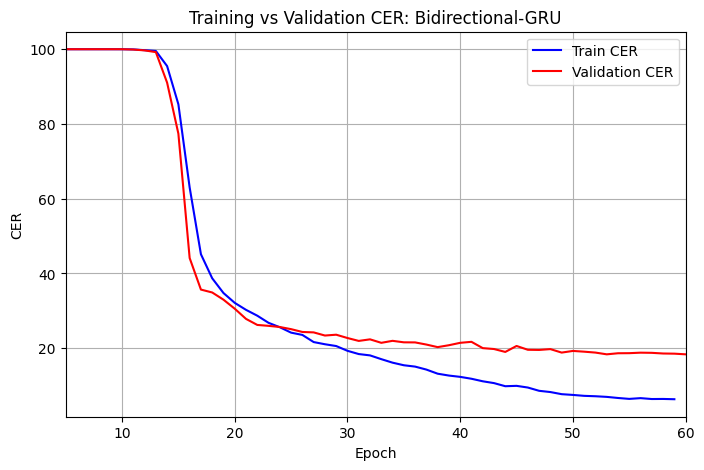

In [ ]:
biGRU_path = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-10/02-17-57/lightning_logs/version_0"

plot_cer_from_logs(biGRU_path)


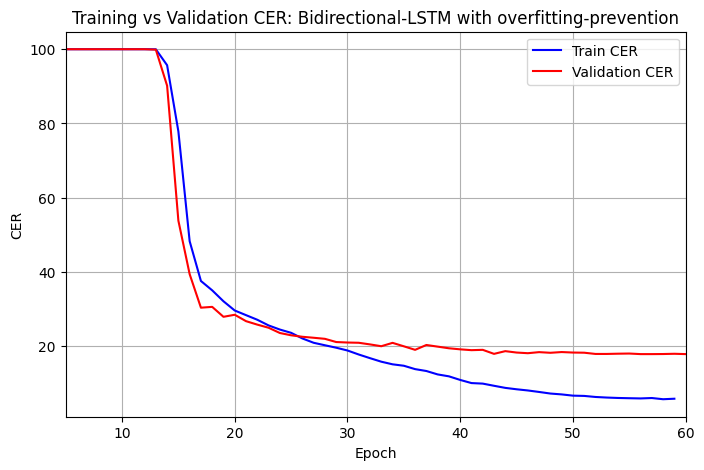

In [ ]:
biLSTM_path_no_overfitting = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-10/22-44-17/lightning_logs/version_0"

plot_cer_from_logs(biLSTM_path_no_overfitting, title="Training vs Validation CER: Bidirectional-LSTM with overfitting-prevention")


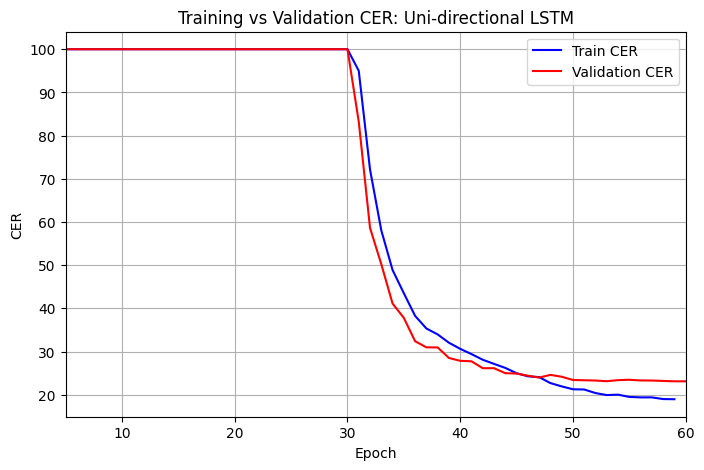

In [ ]:
LSTM_path = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-04/04-27-21/lightning_logs/version_0"
plot_cer_from_logs(LSTM_path, title="Training vs Validation CER: Uni-directional LSTM")

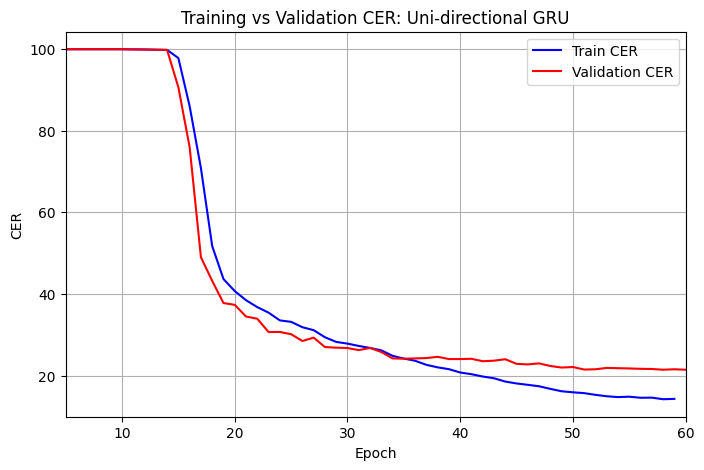

In [ ]:
GRU_path = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-07/22-02-03/lightning_logs/version_0"
plot_cer_from_logs(GRU_path, title="Training vs Validation CER: Uni-directional GRU")

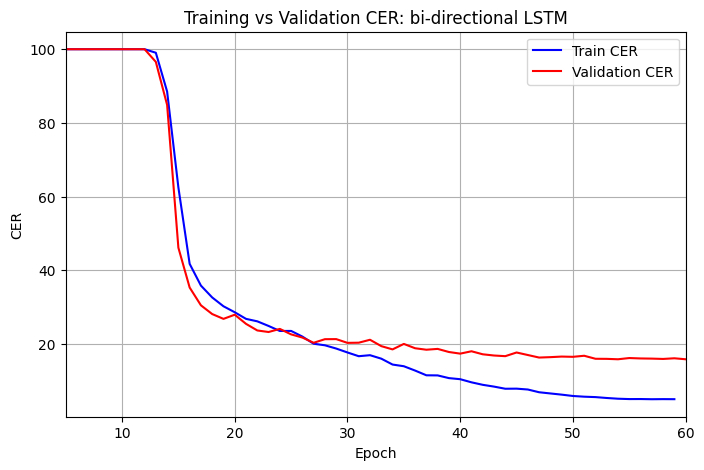

In [ ]:
biLSTM_path = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-07/22-05-08/lightning_logs/version_0"
plot_cer_from_logs(biLSTM_path, title="Training vs Validation CER: bi-directional LSTM")

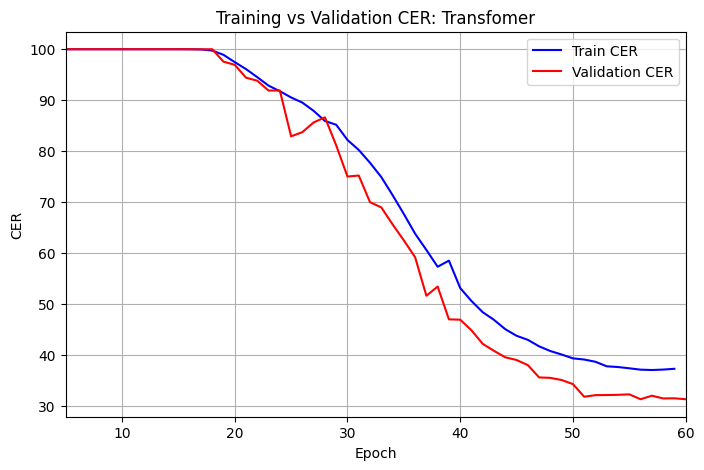

In [ ]:
transformer_graph = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-12/1-1-1/version_0"
baseline_graph = '/content/drive/MyDrive/emg2qwerty/logs/2026-03-07/1-1-1/version_0'
plot_cer_from_logs(transformer_graph, title="Training vs Validation CER: Transfomer")

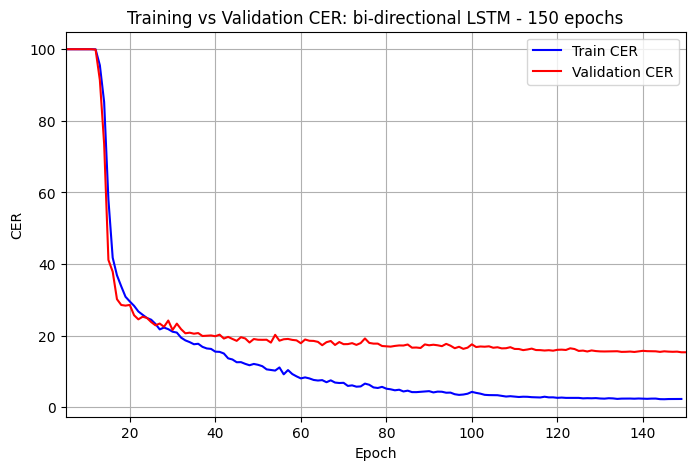

In [ ]:
final_model = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-12/20-09-44/lightning_logs/version_0"
plot_cer_from_logs(final_model, title="Training vs Validation CER: bi-directional LSTM - 150 epochs")

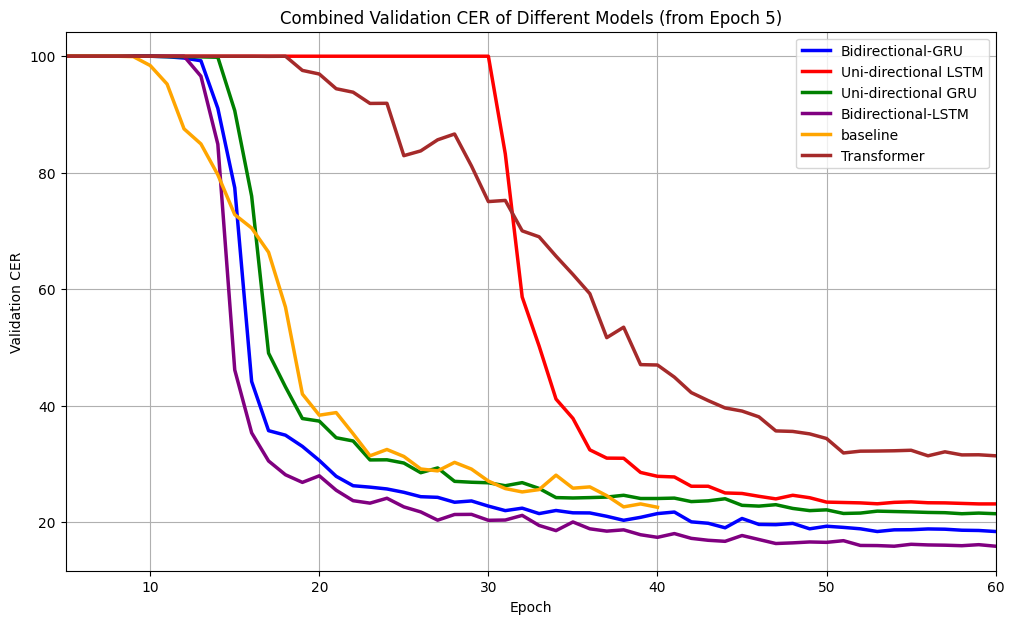

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Helper function to map steps to epochs
def step_to_epoch(metric_steps, epoch_steps, epochs):
    epoch_idx = 0
    result = []
    for step in metric_steps:
        while epoch_idx + 1 < len(epoch_steps) and step >= epoch_steps[epoch_idx + 1]:
            epoch_idx += 1
        result.append(epochs[epoch_idx])
    return result

# Log directories for each model (using the variables already defined)
log_paths = {
    "Bidirectional-GRU": biGRU_path,
    "Uni-directional LSTM": LSTM_path,
    "Uni-directional GRU": GRU_path,
    "Bidirectional-LSTM": biLSTM_path,
    "baseline": baseline_path,
    "Transformer": transformer_graph,
}

start_epoch = 5 # Consistent with previous individual plots

plt.figure(figsize=(12, 7))

all_epochs = []

# Define a list of distinct colors
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan']
color_idx = 0

for label, log_dir in log_paths.items():
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()

    # Extract epoch info
    epoch_events = ea.Scalars("epoch")
    epoch_steps = [x.step for x in epoch_events]
    epochs = [x.value for x in epoch_events]

    # Extract validation CER metrics
    val_cer_events = ea.Scalars("val/CER")
    val_steps = [x.step for x in val_cer_events]
    val_values = [x.value for x in val_cer_events]

    val_epochs = step_to_epoch(val_steps, epoch_steps, epochs)

    # Filter epochs >= start_epoch, and for baseline, also filter <= 40
    val_filtered = [(e, v) for e, v in zip(val_epochs, val_values) if e >= start_epoch and (label != "baseline" or e <= 40)]
    if val_filtered: # Ensure there's data after filtering
        filtered_val_epochs, filtered_val_values = zip(*val_filtered)
        plt.plot(filtered_val_epochs, filtered_val_values, label=label, color=colors[color_idx % len(colors)], linewidth=2.5)
        all_epochs.extend(filtered_val_epochs)
        color_idx += 1

plt.xlabel("Epoch")
plt.ylabel("Validation CER")
plt.title("Combined Validation CER of Different Models (from Epoch 5)")
plt.legend()
plt.grid(True)

if all_epochs:
    plt.xlim(start_epoch, max(all_epochs))
plt.autoscale(enable=True, axis='y')

plt.show()